<a href="https://colab.research.google.com/github/Mikhailo88/MN-Praktychni-K4/blob/main/%D0%9B%D0%B12_2_%D0%9E%D0%BB%D1%8C%D1%85%D0%BE%D0%B2%D0%B5%D0%BD%D0%BA%D0%BE_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import math

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [23]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [24]:
df = pd.read_csv("titanic.csv")

In [25]:
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Набір даних зазвичай містить такі стовпці:

PassengerId: Унікальний ідентифікатор для кожного пасажира.

Survived: У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

Pclass (Клас квитка): Показник соціально-економічного статусу, де 1 – найвищий клас, а 3 – найнижчий.

Name: Ім'я пасажира.

Sex: Стать пасажира.

Age: Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

SibSp: Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

Parch: Кількість батьків або дітей пасажира на борту «Титаніка».

Ticket: Номер квитка.

Fare: Сума грошей, яку пасажир сплатив за квиток.

Головна мета використання цього набору даних — передбачити, чи вижив пасажир, на основі різних ознак. Він слугує популярним вступним набором даних для тих, хто вивчає аналіз даних, машинне навчання та прогнозне моделювання. Майте на увазі, що набір даних може змінюватися та оновлюватися, тому завжди гарною ідеєю є перевірити веб-сайт Kaggle або документацію набору даних, щоб отримати найактуальнішу інформацію.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Замінюємо пропущені значення на середнє

In [28]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

# Текстові дані
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [29]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [30]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [31]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [32]:
df["Sex"] = df["Sex"].str.strip().str.lower().map({"male": 0,"female": 1})

print(df.dtypes)

Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


In [33]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,13.002015,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,29.699118,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [34]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [35]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [36]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.000000,13.00
887,1,1,1,19.000000,30.00
888,0,3,1,29.699118,23.45
889,1,1,0,26.000000,30.00
890,0,3,0,32.000000,7.75


In [37]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()*100

print(f"Чоловіки: {survival_by_sex[0]:.2f}%")
print(f"Жінки: {survival_by_sex[1]:.2f}%")

Чоловіки: 18.89%
Жінки: 74.20%


In [42]:
print(f'Кореляція: {df["Sex"].corr(df["Survived"])}')

Кореляція: 0.5433513806577555


Пасажири залежно від класа у відсотках

In [39]:
class_percent = df["Pclass"].value_counts(normalize=True) * 100

print("Розподіл пасажирів за класами:")
print(class_percent.sort_index())

Розподіл пасажирів за класами:
Pclass
1    24.242424
2    20.650954
3    55.106622
Name: proportion, dtype: float64


Виживші пасажири у відсотках

In [41]:
survival_percent = df.groupby("Pclass")["Survived"].mean() * 100

print("Відсоток тих, хто вижив залежно від класу:")
print(survival_percent)

Відсоток тих, хто вижив залежно від класу:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [43]:
# Розділяємо пасажирів на 6 груп за тарифом Fare
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

# Обчислюємо частку тих, хто вижив у кожній групі
for i in range(6):
    surv_rate = (
        (df[df['Fare_Category'] == i]['Survived'] == 1).sum()
        / (df['Fare_Category'] == i).sum()
    )

    print(f'Частка тих, хто вижив у групі {i}: {surv_rate * 100:.2f}%')

Частка тих, хто вижив у групі 0: 20.51%
Частка тих, хто вижив у групі 1: 19.08%
Частка тих, хто вижив у групі 2: 36.69%
Частка тих, хто вижив у групі 3: 43.62%
Частка тих, хто вижив у групі 4: 41.78%
Частка тих, хто вижив у групі 5: 69.80%


Пасажири з дорожчими квитками мали більший шанс вижити

In [44]:
for i in range(1, 4):
  median_fare = df[df["Pclass"] == i]["Fare"].median()
  print(f"Медіана{i}: {median_fare:.2f}")

Медіана1: 60.29
Медіана2: 14.25
Медіана3: 8.05


Перший клас дорожчий за другий у 4 рази. А другий дорожчий за третій майже у 2 рази

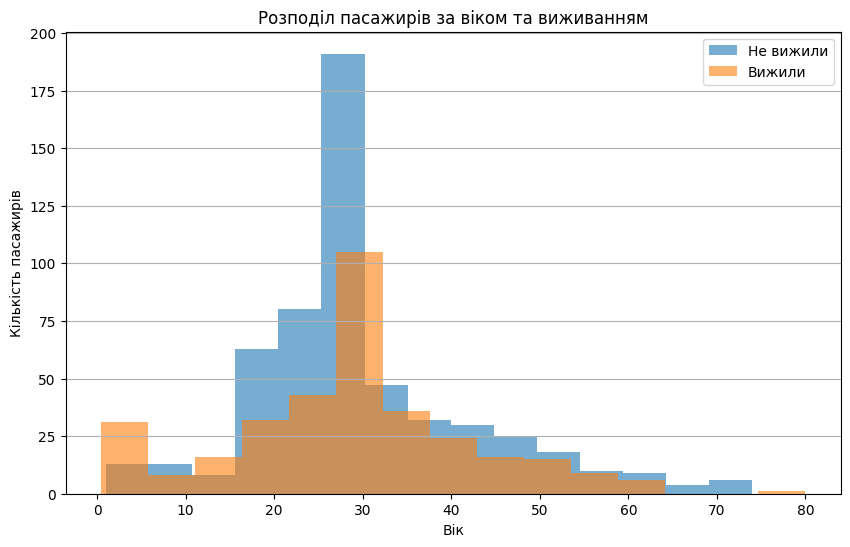

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Не вижив
plt.hist(
    df[df["Survived"] == 0]["Age"],
    bins=15,
    alpha=0.6,
    label="Не вижили"
)

# Вижив
plt.hist(
    df[df["Survived"] == 1]["Age"],
    bins=15,
    alpha=0.6,
    label="Вижили"
)

plt.xlabel("Вік")
plt.ylabel("Кількість пасажирів")
plt.title("Розподіл пасажирів за віком та виживанням")
plt.legend()
plt.grid(axis="y")

plt.show()

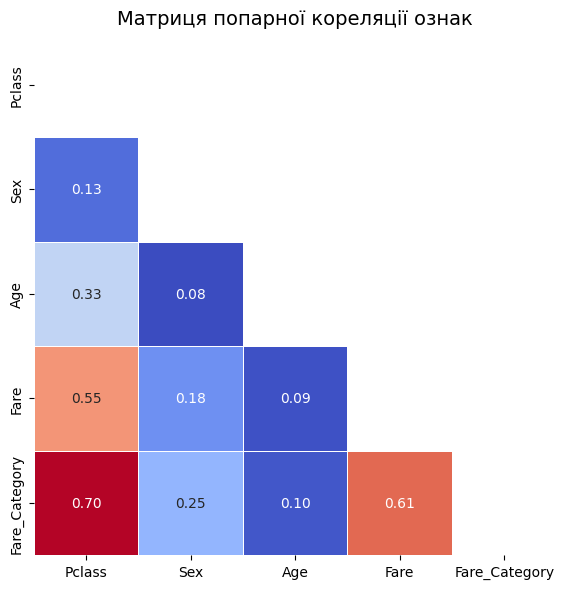

In [50]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляцій
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),  # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

**Висновок:** У ході роботи було проведено аналіз набору даних про пасажирів «Титаніка». Було виконано очищення даних, заповнення пропущених значень та перетворення текстових даних у числовий формат. Досліджено залежність виживання від статі, класу пасажира та вартості квитка, а також побудовано гістограму розподілу пасажирів за віком. За результатами аналізу можна побачити, що стать, клас пасажира та вартість квитка пов'язані з імовірністю виживання.